In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Base Estimators
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import xgboost as xgb

# Stacking Mechanism
from sklearn.ensemble import StackingClassifier

# Random State Initialization for Reproducibility
RANDOM_STATE = 0

Data preprocessing

In [3]:
from pathlib import Path
DATA_DIR = Path.cwd().parent / "data"

train_file_name = "UNSW_NB15_training-set.csv"  
test_file_name = "UNSW_NB15_testing-set.csv"    

train_path = DATA_DIR / train_file_name
test_path = DATA_DIR / test_file_name

print(f"Loading Training Data from: {train_path.resolve()}")
print(f"Loading Testing Data from:  {test_path.resolve()}")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

#Standardize Column Names 
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

#Clean up metadata/index columns to prevent data leakage
leakage_cols = ['id', 'Flow ID', 'Source IP', 'Src IP', 'Destination IP', 'Dst IP', 'Timestamp', 'External IP', 'attack_cat']
for df in [train_df, test_df]:
    df.drop(columns=[col for col in leakage_cols if col in df.columns], inplace=True, errors='ignore')

#Handle infinite and NaN values (highly common in flow datasets)
for df in [train_df, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

#Encode categorical columns if they exist (e.g., proto, service, state in UNSW-NB15)
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
# Exclude the target label if it is stored as a string
if 'Label' in categorical_cols:
    categorical_cols.remove('Label')
if 'label' in categorical_cols:
    categorical_cols.remove('label')

if categorical_cols:
    print(f"Encoding categorical features: {categorical_cols}")
    for col in categorical_cols:
        # Map categories to their frequency in the training set
        freq_map = train_df[col].value_counts(normalize=True).to_dict()
        train_df[col] = train_df[col].map(freq_map).fillna(0)
        test_df[col] = test_df[col].map(freq_map).fillna(0)

# Map Target Label to Binary (0 = Benign, 1 = Attack)
# Standardize 'Label' vs 'label' casing
for df in [train_df, test_df]:
    if 'Label' in df.columns and 'label' not in df.columns:
        df.rename(columns={'Label': 'label'}, inplace=True)

# Convert string target labels (like 'BENIGN' / 'ATTACK') to binary 0 and 1
for df in [train_df, test_df]:
    if df['label'].dtype == 'object':
        df['label'] = df['label'].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)

# 8. Separate features and target
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

# 9. Scale Features
print("--- Scaling Features ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data ready! Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Loading Training Data from: C:\Users\mad\miniconda3\envs\xai_ids\data\UNSW_NB15_training-set.csv
Loading Testing Data from:  C:\Users\mad\miniconda3\envs\xai_ids\data\UNSW_NB15_testing-set.csv
Encoding categorical features: ['proto', 'service', 'state']
--- Scaling Features ---
Data ready! Train shape: (82332, 42), Test shape: (175341, 42)


Rename dataframes


In [4]:
feature_names = {
    'dur': 'Connection Duration',
    'proto': 'Network Protocol',
    'service': 'Network Service',
    'state': 'Connection State',
    'spkts': 'Source Packets',
    'dpkts': 'Destination Packets',
    'sbytes': 'Source Bytes',
    'dbytes': 'Destination Bytes',
    'rate': 'Connection Rate',
    'sttl': 'Source Time-To-Live (TTL)',
    'dttl': 'Destination Time-To-Live (TTL)',
    'sload': 'Source Traffic Load',
    'dload': 'Destination Traffic Load',
    'sloss': 'Source Packet Loss',
    'dloss': 'Destination Packet Loss',
    'sinpkt': 'Source Packet Interval',
    'dinpkt': 'Destination Packet Interval',
    'sjit': 'Source Jitter',
    'djit': 'Destination Jitter',
    'swin': 'Source TCP Window Size',
    'stcpb': 'Source TCP Base Sequence',
    'dtcpb': 'Destination TCP Base Sequence',
    'dwin': 'Destination TCP Window Size',
    'tcprtt': 'TCP Round Trip Time',
    'synack': 'SYN-ACK Response Time',
    'ackdat': 'ACK Data Response Time',
    'smean': 'Mean Source Packet Size',
    'dmean': 'Mean Destination Packet Size',
    'trans_depth': 'HTTP Transaction Depth',
    'response_body_len': 'HTTP Response Body Length',
    'ct_srv_src': 'Connections to Same Service from Source',
    'ct_state_ttl': 'Connections by State and TTL',
    'ct_dst_ltm': 'Connections to Destination (Recent)',
    'ct_src_dport_ltm': 'Source to Destination Port Connections',
    'ct_dst_sport_ltm': 'Destination to Source Port Connections',
    'ct_dst_src_ltm': 'Source-Destination Connection Count',
    'is_ftp_login': 'FTP Login Status',
    'ct_ftp_cmd': 'FTP Command Count',
    'ct_flw_http_mthd': 'HTTP Method Count',
    'ct_src_ltm': 'Recent Source Connections',
    'ct_srv_dst': 'Connections to Same Service & Destination',
    'is_sm_ips_ports': 'Same IP and Port Indicator'
}

X_train = X_train.rename(columns=feature_names)
X_test = X_test.rename(columns=feature_names)

Extrapolating top features from Random Forest model


--- Running Baseline Feature Importance (Random Forest) ---


C:\Users\mad\AppData\Local\Temp\ipykernel_16092\2231470102.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")


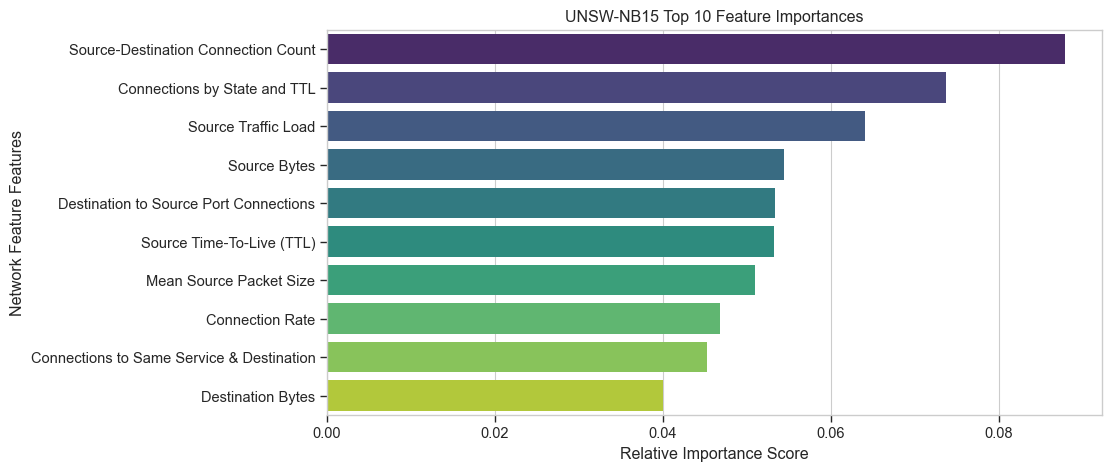

In [5]:
print("\n--- Running Baseline Feature Importance (Random Forest) ---")
fi_model = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
fi_model.fit(X_train_scaled, y_train)

# Extrapolate top 10 features 
importances = fi_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")
plt.title("UNSW-NB15 Top 10 Feature Importances")
plt.xlabel("Relative Importance Score")
plt.ylabel("Network Feature Features")
plt.show()

Train various ML models


In [6]:
performance_metrics = {}
trained_models = {}

def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):

    print(f"Training {name}...")

    model.fit(X_tr, y_tr)

    trained_models[name] = model

    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    performance_metrics[name] = {

        "Accuracy":acc,
        "Precision":prec,
        "Recall":rec,
        "F1-Score":f1

    }

    print(f"{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}\n")

    return y_pred

In [7]:
# Evaluate Base Learners
y_pred_dt = evaluate_model(DecisionTreeClassifier(random_state=RANDOM_STATE), "Decision Tree", X_train_scaled, y_train, X_test_scaled, y_test)
y_pred_rf = evaluate_model(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), "Random Forest", X_train_scaled, y_train, X_test_scaled, y_test)
y_pred_xg = evaluate_model(xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'), "XGBoost Base", X_train_scaled, y_train, X_test_scaled, y_test)

Training Decision Tree...
Decision Tree
Accuracy : 0.8957
Precision: 0.9812
Recall   : 0.8632
F1 Score : 0.9184

Training Random Forest...
Random Forest
Accuracy : 0.9009
Precision: 0.9874
Recall   : 0.8655
F1 Score : 0.9224

Training XGBoost Base...
XGBoost Base
Accuracy : 0.9021
Precision: 0.9878
Recall   : 0.8669
F1 Score : 0.9234



Train hybrid Stacking DL + ML model

In [8]:
print("--- Initializing Validated Stacking Architecture ---")

# Define base structure
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ('et', ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ('xg', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
]

# Meta-learner to optimize final predictions
meta_learner = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_estimators=50)

# Build unified StackingClassifier with 5-Fold cross validation
stacking_pipeline = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5, 
    n_jobs=-1,
    passthrough=False
)

# Run engine
y_pred_stk = evaluate_model(stacking_pipeline, "Stacking Model (Hybrid Engine)", X_train_scaled, y_train, X_test_scaled, y_test)

--- Initializing Validated Stacking Architecture ---
Training Stacking Model (Hybrid Engine)...
Stacking Model (Hybrid Engine)
Accuracy : 0.8961
Precision: 0.9897
Recall   : 0.8563
F1 Score : 0.9181



Performance comparison table

                                Accuracy  Precision  Recall  F1-Score
Decision Tree                     0.8957     0.9812  0.8632    0.9184
Random Forest                     0.9009     0.9874  0.8655    0.9224
XGBoost Base                      0.9021     0.9878  0.8669    0.9234
Stacking Model (Hybrid Engine)    0.8961     0.9897  0.8563    0.9181


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.895655,0.981245,0.863190,0.918439
Random Forest,0.900902,0.987353,0.865486,0.922412
XGBoost Base,0.902077,0.987778,0.866852,0.923373
Stacking Model (Hybrid Engine),0.896077,0.989666,0.856252,0.918138


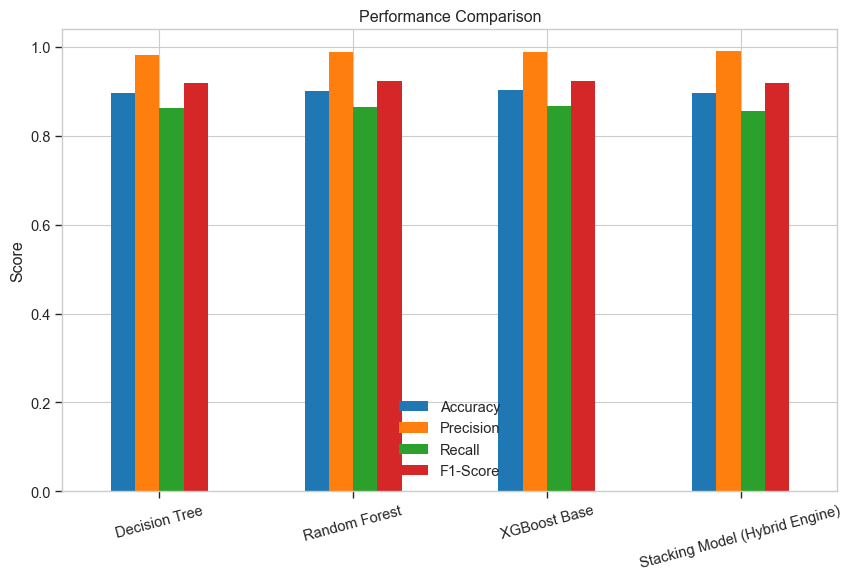

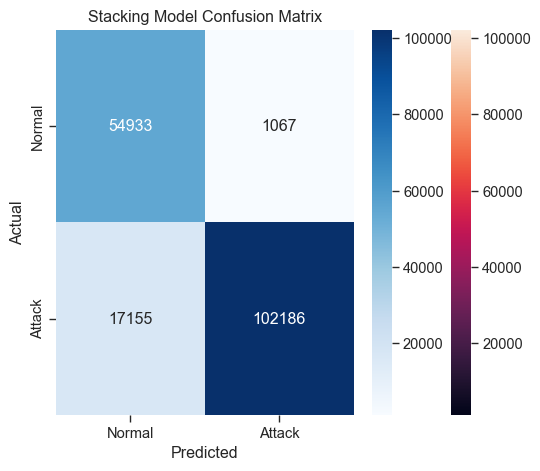

In [9]:

results_df = pd.DataFrame(performance_metrics).T

print(results_df.round(4))

display(results_df.style.background_gradient(cmap="Blues"))

results_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred_stk)

sns.heatmap(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.title("Stacking Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Correlation heatmap

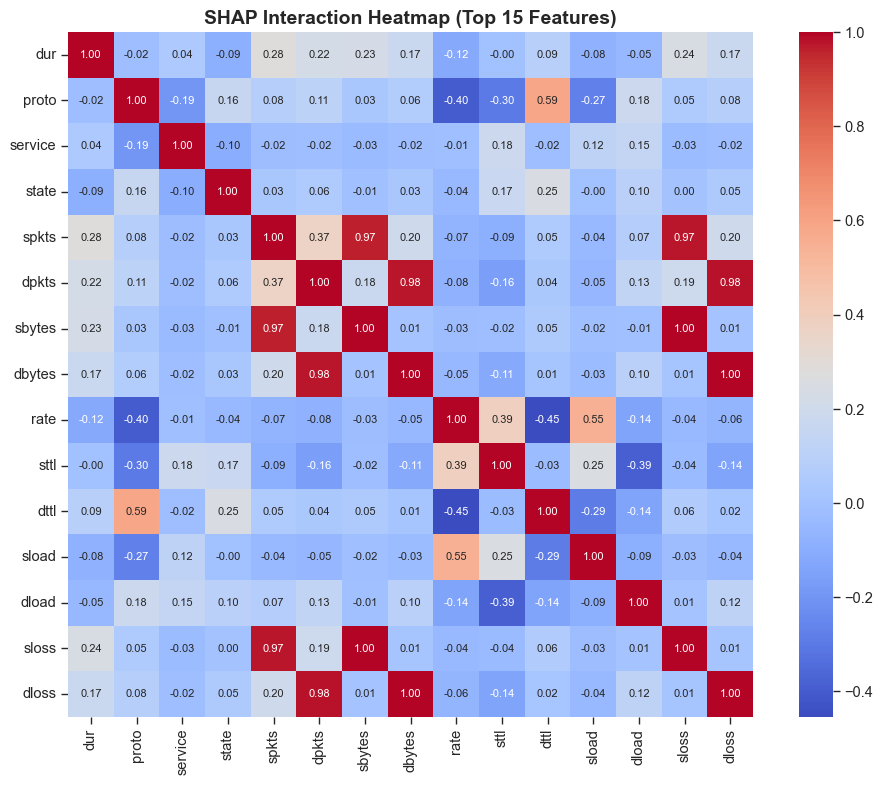

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set clean visualization parameters for papers
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
fig_color = "#2b5c8f"

# Showing correlation of top features to keep the visual readable
plt.figure(figsize=(10, 8))
# Identify numeric columns from your scaled feature matrix
numeric_cols = train_df.select_dtypes(include=[np.number]).columns[:15] # Top 15 features for clean viewing
corr_matrix = train_df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,
            annot_kws={"size": 8})
plt.title("SHAP Interaction Heatmap (Top 15 Features)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

SHAP integration

Generating SHAP Analysis...


PermutationExplainer explainer: 501it [01:17,  6.43it/s]                         


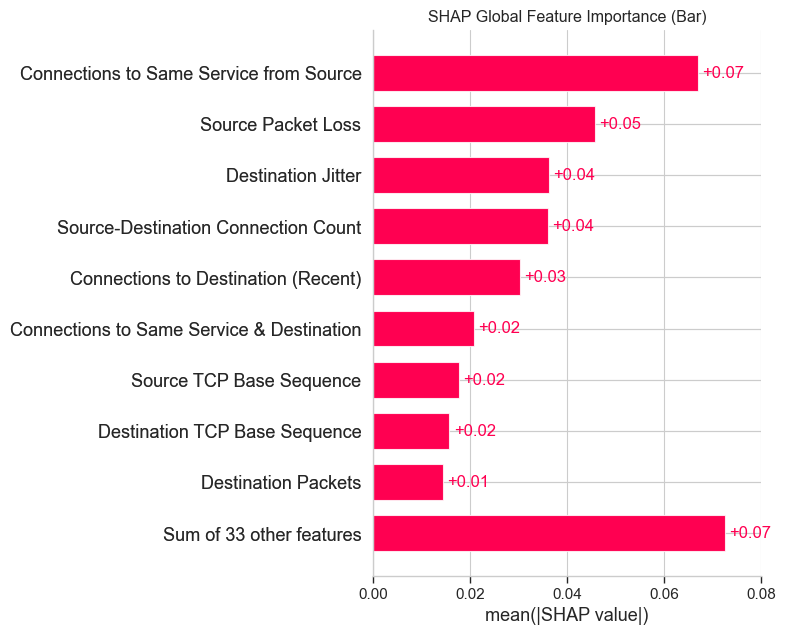

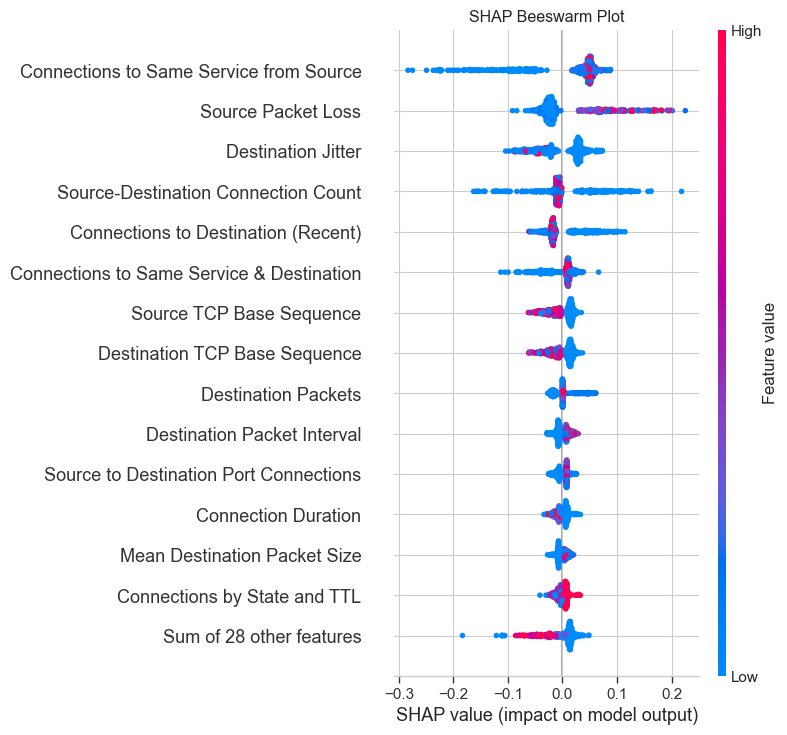

In [11]:
import shap
import matplotlib.pyplot as plt

print("Generating SHAP Analysis...")

# 1. Fetch model wrapper
best_model = trained_models["XGBoost Base"]

# 2. Rename dataset columns
X_test_named = X_test.rename(columns=feature_names)

# 3. Downsample rows to keep execution fast
X_test_sampled = X_test_named.sample(n=min(500, len(X_test_named)), random_state=42)

# 4. FIXED: Using .predict_proba tells SHAP to treat it as a function callback,
# avoiding the C++ TreeExplainer parameter parser bug entirely.
explainer = shap.Explainer(best_model.predict_proba, X_test_sampled)

# 5. Compute SHAP values
shap_values = explainer(X_test_sampled)

# 6. Extract the probabilities for the positive class (Class 1) 
# to keep plot dimensions correct for binary/multi-class outcomes
if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

# 7. Generate Bar Plot
plt.figure(figsize=(12, 6))
shap.plots.bar(shap_values_plot, show=False)
plt.title("SHAP Global Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# 8. Generate Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values_plot,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()


SHAP Global Importance Chart